## Lung matched data- Dot plots
### NK markers
### Pydeseq2- DEG's irt iML vs cNK in tumor
### Pydeseq2- DEG's irt iML in tumor vs iML in normal

In [ ]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

In [2]:
#load malm data

In [3]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/profiling/updated_batch_pan_cancer_v4_dataset_v2_PtID_v2_extra_datasets_removal/pan_cancer_eMLclassified_adata_batch_dataset_v2_after_extra_datasets_removed_classification_allGenes.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 82408 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs["classification"].value_counts()

classification
CD56dim          65194
ML1               5371
CD56bright        4839
ML_transition     2898
ML2               2617
unclassified      1489
Name: count, dtype: int64

In [8]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
#subset to include only lung tumor data

In [9]:
adata_tumor = adata[adata.obs["source"].isin(["lung_tumor"])].copy()

In [10]:
adata_tumor.obs["patient_ID_v2"].nunique()

93

In [11]:
unique_counts = adata_tumor.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()
print(unique_counts)

dataset_v2
bischoff       10
chan           14
kim            11
lambrechts      8
leader         28
leader_cite     8
chen_J         10
he_D            5
Name: patient_ID_v2, dtype: int64


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_23940/1224505341.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_counts = adata_tumor.obs.groupby('dataset_v2')['patient_ID_v2'].nunique()


In [12]:
#filtering adata by patients with multiple sources and focus on lung

In [13]:
# Step 1: Count unique sources per patient
patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()

# Step 2: Identify patients with >1 unique source
patients_multiple_sources = patient_source_counts[patient_source_counts > 1].index

# Step 3: Filter adata to only include those patients
adata_filtered = adata[adata.obs["patient_ID_v2"].isin(patients_multiple_sources)].copy()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_23940/1508113905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_source_counts = adata.obs.groupby("patient_ID_v2")["source"].nunique()


In [14]:
adata_filtered.obs["patient_ID_v2"].nunique()

77

In [ ]:
#subsetted to include matched lung data

In [15]:
adata_filtered = adata_filtered[adata_filtered.obs["source"].isin(["lung_normal", "lung_tumor"])].copy()

In [16]:
adata_filtered

AnnData object with n_obs × n_vars = 31932 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm', 'counts'
    obsp: 'connectivities', 'di

In [17]:
adata_filtered.obs["patient_ID_v2"].nunique()

61

In [ ]:
# removing unclassified cells and combining iML1, iML2, iML_transition to iML categories

In [18]:
adata_v2 = adata_filtered[adata_filtered.obs['classification'] != 'unclassified', :]
adata_v2.obs['group'] = adata_filtered.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_23940/2083872055.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_v2.obs['group'] = adata_filtered.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})
/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_23940/2083872055.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_v2.obs['group'] = adata_filtered.obs['classification'].replace({ 'ML1': 'iML', 'ML2':'iML', 'ML_transition':'iML'})


In [19]:
adata_v2

AnnData object with n_obs × n_vars = 31585 × 14337
    obs: 'sample', 'batch', 'subset', 'dataset', 'source', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'tissue_residency_auc', 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_auc', 'HALLMARK_TGF_BETA_SIGNALING_auc', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION_auc', 'GOBP_RESPONSE_TO_PROSTAGLANDIN_auc', 'HALLMARK_HYPOXIA_auc', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY_auc', 'HALLMARK_MTORC1_SIGNALING_auc', 'HALLMARK_NOTCH_SIGNALING_auc', 'KEGG_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY_auc', 'HALLMARK_GLYCOLYSIS_auc', 'HALLMARK_WNT_BETA_CATENIN_SIGNALING_auc', 'subset_source', 'bright_dim_subset', 'reference', 'Malmberg_patient', 'patient_ID', 'dataset_v2', 'patient_ID_v2', 'classification', 'group'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'bright_dim_subset_colors', 'neighbors', 'subset_colors', 'subset_source_colors', 'umap', 'log1p'
    obsm: 'X_scVI', 'X_umap'
    layers: 'norm', 'counts'
    obsp: 'connectivit

In [20]:
adata_v2.obs["group"].value_counts()

group
CD56dim         27181
iML              3328
CD56bright       1076
unclassified        0
Name: count, dtype: int64

In [21]:
adata_v2.obs['group'] = adata_v2.obs['group'].cat.remove_unused_categories()


In [22]:
# scaled gene expression

In [23]:
sc.pp.scale(adata_v2, zero_center=True, max_value=None)

In [25]:
adata_v2.obs['group'].unique()


['CD56dim', 'iML', 'CD56bright']
Categories (3, object): ['CD56bright', 'CD56dim', 'iML']

In [28]:

adata_v2.obs['group_source'] = adata_v2.obs['group'].astype(str) + '_' + adata_v2.obs['source'].astype(str)

In [33]:
marker_genes_dict = {
    "CD56bright": ["XCL2", "XCL1", "SELL"],
    "CD56dim": ["FGFBP2", "SPON2", "KLF2", "FCGR3A"],
    "iML": ["KLRC1", "TNFRSF18", "HLA-DRB1", "HLA-DPA1","CD2","COTL1", "SOCS1", "MIF" 
         ,"PDCD4", "CD96", "TOX2", "TIGIT","LAG3", "ENTPD1"],
    "Adaptive": ["KLRC2","ZBTB16", "FCER1G", "SH2D1B", "SYK"],
    "Tissue resident & ILC": ["ITGA1", "ZNF683", "RORC", "IL1R1", "CCR6","TBX21", "AHR", "EOMES"],

}

In [36]:
#edited
marker_genes_dict = {
    "CD56bright": ["XCL2", "XCL1", "SELL"],
    "CD56dim": ["FCGR3A"],
    "iML": ["TNFRSF18", "HLA-DPA1","CD2","COTL1", "SOCS1", "MIF" 
         ,"PDCD4", "TOX2","LAG3", "ENTPD1"],
    "Adaptive": ["ZBTB16", "FCER1G", "SH2D1B", "SYK"],
    "Tissue resident & ILC": [ "ZNF683", "RORC", "IL1R1", "CCR6","TBX21", "AHR", "EOMES"],

}

In [39]:
plt.rcParams['figure.dpi'] = 600

categories: CD56bright, CD56dim, iML
var_group_labels: CD56bright, CD56dim, iML, etc.


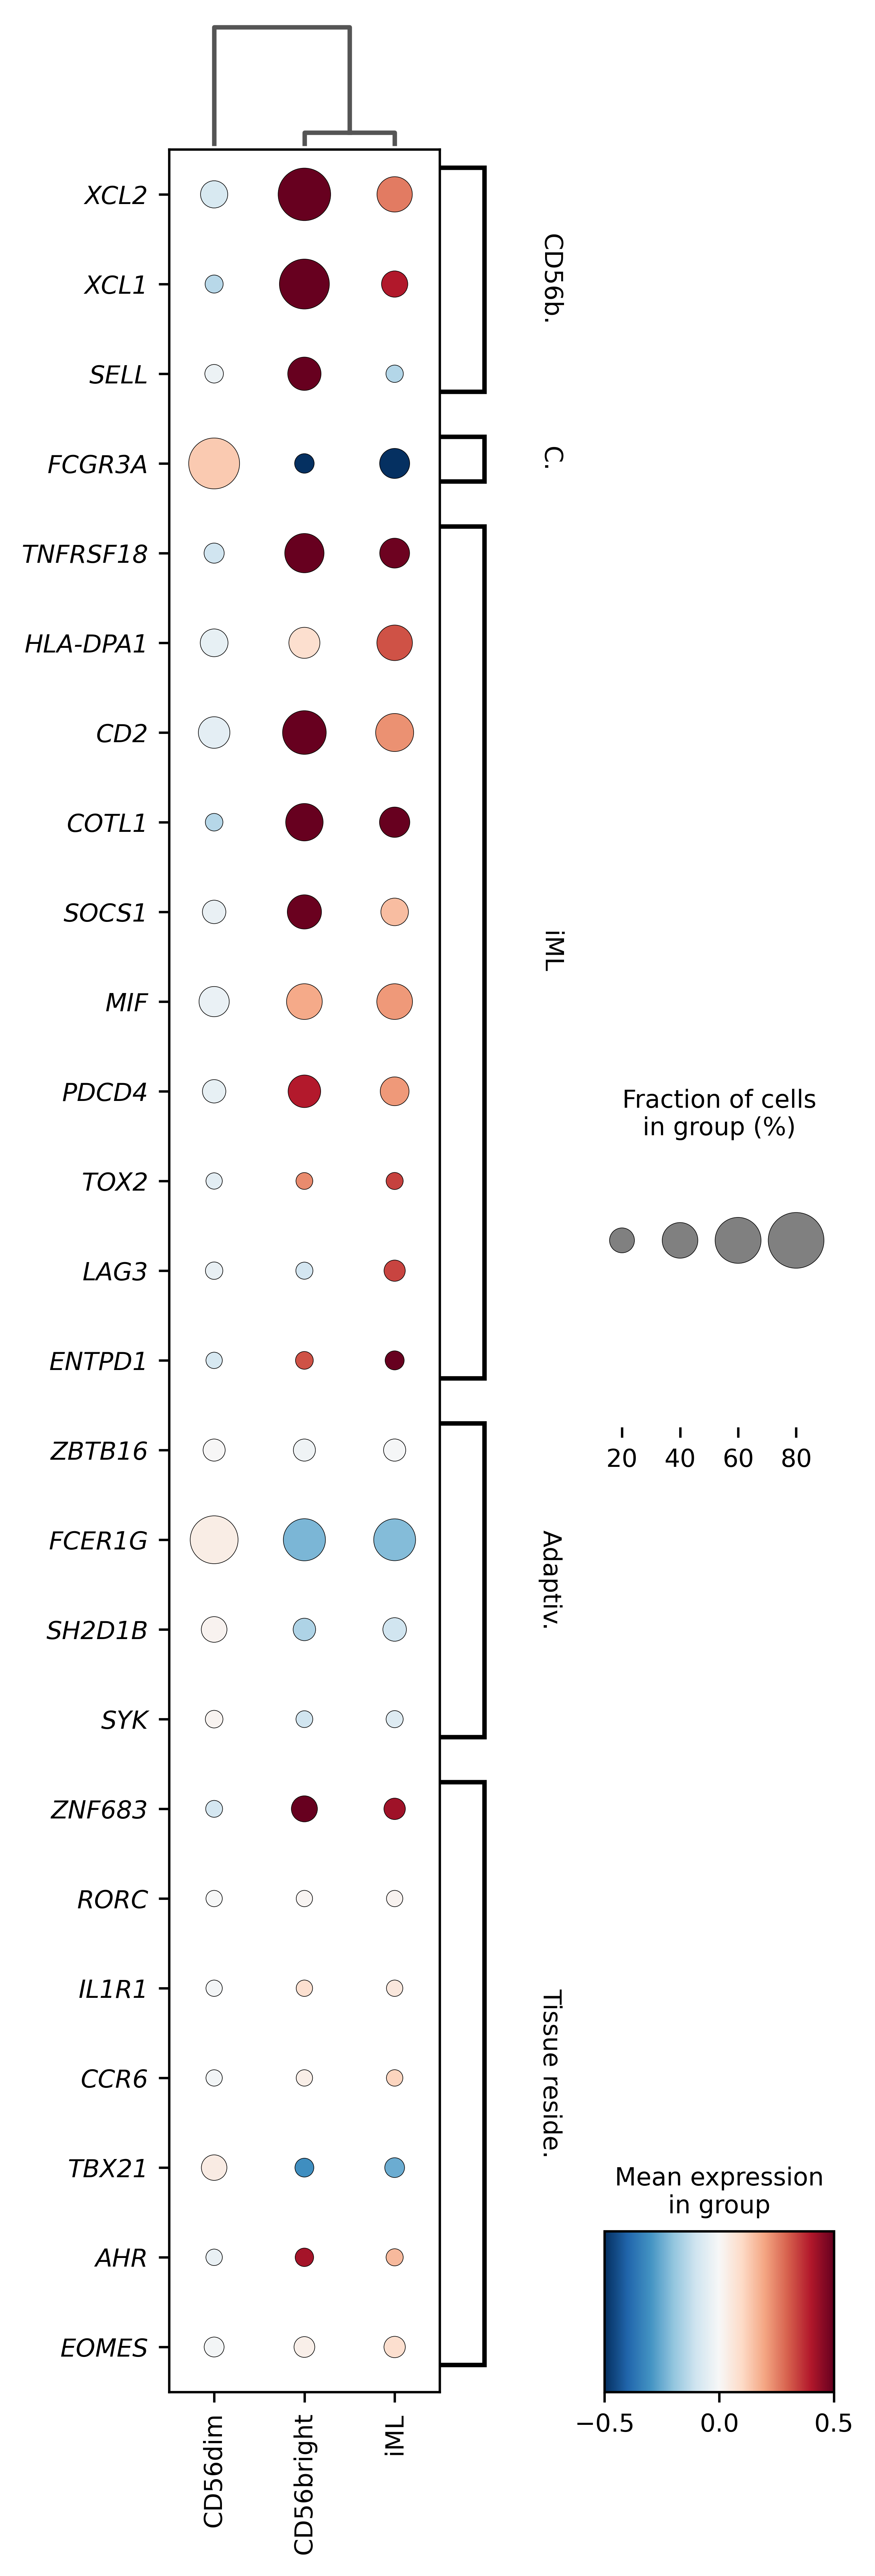

In [40]:
dp = sc.pl.dotplot(
    adata_v2,
    marker_genes_dict,
    "group",
    dendrogram=True,
    use_raw=False,
    vmax=0.5,
    vmin=-0.5,
    show=False,
    swap_axes=True,
    color_map='RdBu_r',
    return_fig=True,figsize=(4, 14)
)

dp.style(
    smallest_dot=30,
    largest_dot=350,
    cmap='RdBu_r',
    color_on='white'
)

ax = dp.get_axes()
for label in ax['mainplot_ax'].get_yticklabels():
    label.set_fontstyle('italic')

plt.show()


In [ ]:
#Pyedeseq2 - DEG's

In [ ]:
sc.pp.scale(adata_filtered, zero_center=True, max_value=None)

In [ ]:
# combining bright and dim cells -> cNK
# combining iML1, iML2, iML_transition -> iML

In [ ]:
adata_filtered = adata_filtered[adata_filtered.obs['classification'] != 'unclassified'].copy()
adata_filtered.obs['classification'] = adata_filtered.obs['classification'].replace({
    'CD56bright': 'cNK',
    'CD56dim': 'cNK',
    'ML1': 'iML',
    'ML2': 'iML',
    'ML_transition': 'iML'
})
adata_filtered.obs['classification'] = adata_filtered.obs['classification'].astype('category')

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_56224/1755223510.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_filtered.obs['classification'] = adata_filtered.obs['classification'].replace({


In [ ]:
# Create a new column 'combined' by joining 'classification' and 'source'
adata_filtered.obs['classification_source'] = adata_filtered.obs['classification'].astype(str) + "_" + adata_filtered.obs['source'].astype(str)

In [ ]:
adata_filtered.obs["classification_source"].value_counts()

classification_source
cNK_lung_normal    18811
cNK_lung_tumor      9446
iML_lung_tumor      1902
iML_lung_normal     1426
Name: count, dtype: int64

In [ ]:
#plot the important genes- Lung matched iML tumor vs cNK tumor

### Dotplot - DEG's irt iML lung tumor vs cNK lung tumor

In [ ]:
genes=[ "TOX2", "LAG3", "CCR1", "CD200R1", "CD9", "HLA-DQA1", "HLA-DQB1", "IRF4", 
    "KLRC1", "KIR2DL4", "KLRC2", "GZMA", "ITGAE", "TOX", "TNFSF10", 
    "TIGIT",   "GZMK", "CXCR6", "CCR5", "DBN1", "ITGA1"
     , 'ITM2C', 'DUSP4', 'HLA-DRB1', 'CD44', 'CD96', 'CD74', 'IKZF3',
       "CXCR3",
      "S1PR5",  "FGFBP2", "PLAC8", "SPON2", "CX3CR1", "PTGDS","KLF3","KLF2","LAIR2", "TGFBR3", "B3GAT1", "CD226", 
     "IL7R", "LAIR1", "TNF", "CD6", "IL12RB1", "GZMH", "TBX21", "CD300A", 
    "NFATC2", "ITGAX", "GZMM","ICAM2", 'NR4A2']

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_4580/1395562866.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_data.groupby('classification_source')[genes]


Genes passing 20% expression threshold (only in 'cNK_lung_tumor' or 'iML_lung_tumor'): [np.str_('HLA-DQB1'), np.str_('KLRC1'), np.str_('KIR2DL4'), np.str_('KLRC2'), np.str_('GZMA'), np.str_('ITGAE'), np.str_('TIGIT'), np.str_('GZMK'), np.str_('ITGA1'), np.str_('ITM2C'), np.str_('DUSP4'), np.str_('HLA-DRB1'), np.str_('CD44'), np.str_('CD96'), np.str_('CD74'), np.str_('IKZF3'), np.str_('S1PR5'), np.str_('FGFBP2'), np.str_('PLAC8'), np.str_('SPON2'), np.str_('CX3CR1'), np.str_('PTGDS'), np.str_('KLF2'), np.str_('LAIR2'), np.str_('GZMH'), np.str_('CD300A'), np.str_('GZMM'), np.str_('NR4A2')]


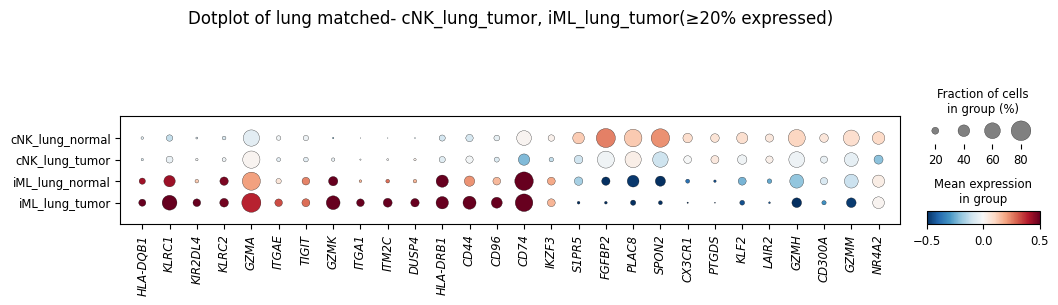

In [ ]:
# Compute fraction of cells expressing each gene per group
expr_data = sc.get.obs_df(adata_filtered, keys=['classification_source'] + genes)

expr_frac = (
    expr_data.groupby('classification_source')[genes]
    .apply(lambda x: (x > 0).sum() / x.shape[0])
)

# Define which groups to apply the threshold to
groups_of_interest = ['cNK_lung_tumor', 'iML_lung_tumor']

# Keep genes expressed in >=20% of cells in at least one of the selected groups
keep_genes = expr_frac.loc[groups_of_interest].columns[
    (expr_frac.loc[groups_of_interest] >= 0.2).any(axis=0)
].tolist()

print("Genes passing 20% expression threshold (only in 'cNK_lung_tumor' or 'iML_lung_tumor'):", keep_genes)

dp = sc.pl.dotplot(
    adata_filtered,
    var_names=keep_genes,
    groupby='classification_source',
    use_raw=False,
    color_map='RdBu_r',  # color scale
    title='Dotplot of lung matched- cNK_lung_tumor, iML_lung_tumor(≥20% expressed)',
    return_fig=True,
    show=False, vmax=0.5, vmin=-0.5
)

# Italicize gene names
ax = dp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()


### Dotplot - DEG's irt iML lung tumor vs iML lung normal

In [ ]:
genes_2=["MKI67",   "KIR3DL2" , "KIR3DL1",  "ZNF683", "HLA-DRA", "NR4A1", 
         "RGS1", "KRT86", "LDLRAD4", "ITM2C",  'CD96', "ARL6IP4",'CCL4', 'TCF25', 'PRF1', 'CCL3', 'RORA',  'KLRF1', 'ITGB2']

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_4580/753739212.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  expr_data.groupby('classification_source')[genes_2]


Genes passing 20% expression threshold (only in 'iML_lung_tumor' or 'iML_lung_normal'): [np.str_('HLA-DRA'), np.str_('RGS1'), np.str_('KRT86'), np.str_('LDLRAD4'), np.str_('ITM2C'), np.str_('CD96'), np.str_('ARL6IP4'), np.str_('CCL4'), np.str_('TCF25'), np.str_('PRF1'), np.str_('CCL3'), np.str_('RORA'), np.str_('KLRF1'), np.str_('ITGB2')]


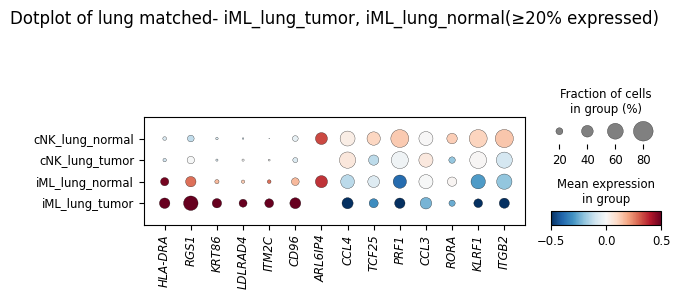

In [ ]:
# Compute fraction of cells expressing each gene per group
expr_data = sc.get.obs_df(adata_filtered, keys=['classification_source'] + genes_2)

expr_frac = (
    expr_data.groupby('classification_source')[genes_2]
    .apply(lambda x: (x > 0).sum() / x.shape[0])
)

# Define which groups to apply the threshold to
groups_of_interest = ['iML_lung_tumor', 'iML_lung_normal']

# Keep genes expressed in >=20% of cells in at least one of the selected groups
keep_genes = expr_frac.loc[groups_of_interest].columns[
    (expr_frac.loc[groups_of_interest] >= 0.2).any(axis=0)
].tolist()

print("Genes passing 20% expression threshold (only in 'iML_lung_tumor' or 'iML_lung_normal'):", keep_genes)

dp = sc.pl.dotplot(
    adata_filtered,
    var_names=keep_genes,
    groupby='classification_source',
    use_raw=False,
    color_map='RdBu_r',  # color scale
    title='Dotplot of lung matched- iML_lung_tumor, iML_lung_normal(≥20% expressed)',
    return_fig=True,
    show=False, vmax=0.5, vmin=-0.5
)

# Italicize gene names
ax = dp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()


In [ ]:
# combining both DEG's list above

In [ ]:
genes = ["HLA-DQB1", "KLRC1", "KIR2DL4", "KLRC2", "GZMA",
    "ITGAE", "TIGIT", "GZMK", "ITGA1", "ITM2C",
    "DUSP4", "HLA-DRB1", "CD44", "CD96", "CD74",
    "IKZF3", "S1PR5", "FGFBP2", "PLAC8", "SPON2",
    "CX3CR1", "KLF2", "LAIR2", "GZMH", "CD300A",
    "GZMM", "NR4A2", "HLA-DRA", "RGS1", "KRT86", "LDLRAD4",  
    "ARL6IP4", "CCL4", "TCF25", "PRF1",
    "CCL3", "RORA", "KLRF1", "ITGB2"]

In [ ]:
plt.rcParams['figure.dpi'] = 600

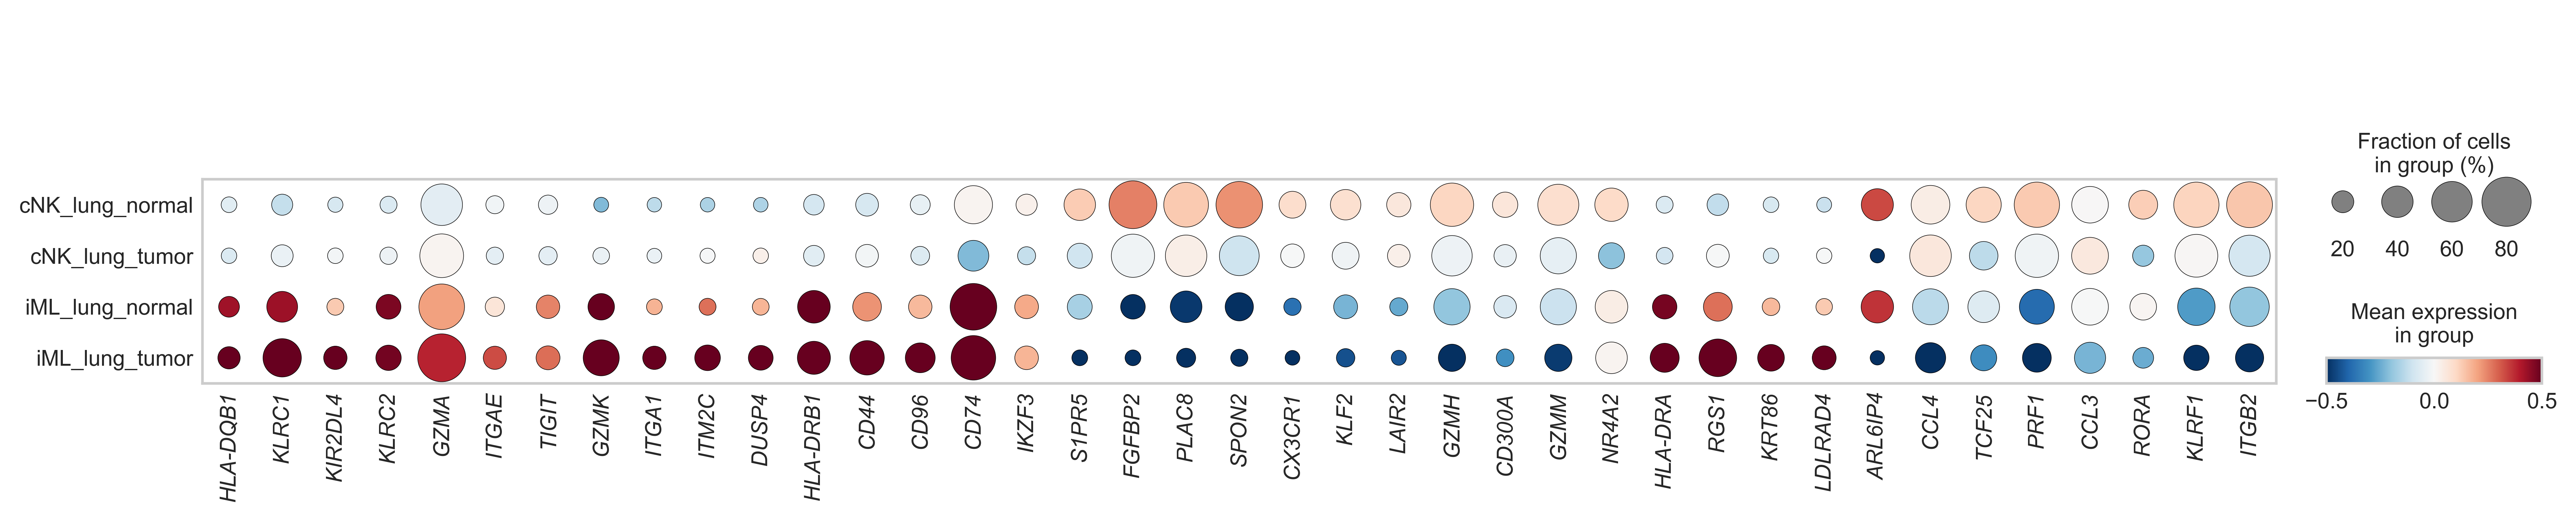

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")  

# Plot the matrixplot with filtered genes
mp = sc.pl.dotplot(
    adata_filtered,
    var_names=genes,
    groupby='classification_source',
    use_raw=False,
    cmap='RdBu_r',
    vmin=-0.5, vmax=0.5,
    return_fig=True,
    show=False,
    swap_axes=False
    ,
    #figsize=(17,4)
)

# Apply Scanpy dotplot theme-like styling
mp.style(
    smallest_dot=30,
    largest_dot=350,
    cmap='RdBu_r',
    color_on='white'
)

#mp.show()

# Italicize gene names
ax = mp.get_axes()
for label in ax['mainplot_ax'].get_xticklabels():
    label.set_fontstyle('italic')

plt.show()
